Physics-constrained random plasma profile generation for ML training data.
The spline code uses the ideas of minimum-spaced knots, PCHIP interpolation, and zero axis derivatives using 'CubicHermiteSpline'

Plasma Profiles
--------
1. Electron temperature, Te(rho)
2. Ion temperature, Ti(rho)
3. Emissivity, epsilon(rho)
4. Perpendicular flow velocity, V_perp(rho)
5. Parallel flow velocity, V_parallel(rho)

The implementation uses:
- PCHIP monotone cubic interpolation
- minimum spacing between random spline knots
- a zero derivative at the magnetic axis where required
- continuous variation between peaked and hollow emissivity
- one electron-root to ion-root transition for perpendicular flow
- fixed-size metadata vectors for machine-learning targets

In [20]:
# (1) Imports

"""
Generate random plasma profiles for machine-learning training data.

Profiles:
    1. Electron temperature
    2. Ion temperature
    3. Emissivity
    4. Perpendicular velocity
    5. Parallel velocity
"""

import json
import numpy as np
import plotly.graph_objects as go

from scipy.interpolate import PchipInterpolator, CubicHermiteSpline
from plotly.subplots import make_subplots

In [21]:
# (2) Helper functions

def random_x_knots(num_knots, minimum_spacing=0.05, x_min=0.0, x_max=1.0):
    """
    Generate sorted random x knot locations with minimum spacing.

    Parameters
    ----------
    num_knots : int
        Total number of knots, including the endpoints.
    minimum_spacing : float
        Minimum distance between neighboring knots.
    x_min : float
        First knot location.
    x_max : float
        Last knot location.

    Returns
    -------
    x_knots : np.ndarray
        Sorted knot locations.
    """
    if num_knots < 2:
        raise ValueError("num_knots must be at least 2.")

    num_interior = num_knots - 2
    num_gaps = num_knots - 1
    available_width = x_max - x_min

    required_width = num_gaps * minimum_spacing
    if required_width > available_width:
        raise ValueError("The minimum spacing is too large for the number of knots.")

    if num_interior == 0:
        return np.array([x_min, x_max])

    extra_width = available_width - required_width
    random_cuts = np.sort(np.random.uniform(0.0, extra_width, num_interior))

    extra_gaps = np.diff(np.concatenate(([0.0], random_cuts, [extra_width])))
    gaps = minimum_spacing + extra_gaps

    x_knots = x_min + np.concatenate(([0.0], np.cumsum(gaps)))

    return x_knots

In [22]:
# (3) Generic spline generators

def spline_with_flat_axis(x_knots, y_knots, flat_axis=True, flat_edge=False):
    """
    Build a PCHIP-based spline and optionally set endpoint derivatives to zero.

    Parameters
    ----------
    x_knots : np.ndarray
        Knot locations.
    y_knots : np.ndarray
        Values at each knot.
    flat_axis : bool
        Set the derivative at rho = 0 to zero.
    flat_edge : bool
        Set the derivative at the final knot to zero.

    Returns
    -------
    spline : CubicHermiteSpline or PchipInterpolator
        Interpolation function.
    """
    pchip = PchipInterpolator(x_knots, y_knots)

    if not flat_axis and not flat_edge:
        return pchip

    derivatives = pchip.derivative()(x_knots)

    if flat_axis:
        derivatives[0] = 0.0
    if flat_edge:
        derivatives[-1] = 0.0

    spline = CubicHermiteSpline(x_knots, y_knots, derivatives)
    
    return spline

In [23]:
# (4) Physics informed profile generators

def generate_temperature_profile(
    rho,
    num_knots=5,
    core_range=(1.0, 5.0),
    minimum_spacing=0.05,
):
    """
    Generate a monotonic decreasing temperature profile.

    The temperature:
        - is largest at the magnetic axis,
        - decreases toward the edge,
        - is zero at the LCFS,
        - has zero derivative at the magnetic axis.

    Returns
    -------
    profile : np.ndarray
        Temperature values on the rho grid.
    parameters : dict
        Parameters used to build the profile.
    """
    x_knots = random_x_knots(num_knots, minimum_spacing)

    core_temperature = np.random.uniform(core_range[0], core_range[1])

    num_interior = num_knots - 2

    interior_y = np.sort(np.random.uniform(0.0, core_temperature, num_interior))[::-1]

    y_knots = np.concatenate(([core_temperature], interior_y, [0.0]))

    spline = spline_with_flat_axis(x_knots, y_knots, flat_axis=True)

    profile = spline(rho)
    profile = np.clip(profile, 0.0, None)

    parameters = {
        "x_knots": x_knots,
        "y_knots": y_knots,
        "core_temperature": core_temperature,
    }

    return profile, parameters

def generate_electron_temperature(rho):
    """
    Generate an electron temperature profile in keV.
    """
    return generate_temperature_profile(
        rho=rho,
        num_knots=5,
        core_range=(1.0, 6.0),
        minimum_spacing=0.05,
    )

def generate_ion_temperature(rho):
    """
    Generate an ion temperature profile in keV.
    """
    return generate_temperature_profile(
        rho=rho,
        num_knots=6,
        core_range=(0.5, 5.0),
        minimum_spacing=0.05,
    )
    
def generate_emissivity(rho):
    """
    Generate an emissivity profile with no more than one off-axis peak.

    The emissivity:
        - can be peaked or hollow,
        - has zero derivative at the magnetic axis,
        - reaches zero before the LCFS,
        - remains zero outside its cutoff radius.

    Returns
    -------
    profile : np.ndarray
        Emissivity values on the rho grid.
    parameters : dict
        Parameters used to build the profile.
    """
    peak_rho = np.random.uniform(0.15, 0.65)
    cutoff_rho = np.random.uniform(max(peak_rho + 0.15, 0.75), 0.98)

    peak_value = np.random.uniform(0.5, 2.0)

    # axis_fraction controls how hollow the profile is.
    # 0.0 gives a strongly hollow profile.
    # 1.0 gives a centrally peaked or nearly flat-core profile.
    axis_fraction = np.random.uniform(0.0, 1.0)
    axis_value = axis_fraction * peak_value

    num_inner_knots = 3
    num_outer_knots = 4

    inner_x = np.linspace(0.0, peak_rho, num_inner_knots)
    outer_x = np.linspace(peak_rho, cutoff_rho, num_outer_knots)

    inner_middle_y = np.sort(np.random.uniform(axis_value, peak_value, num_inner_knots - 2))
    outer_middle_y = np.sort(np.random.uniform(0.0, peak_value, num_outer_knots - 2))[::-1]

    inner_y = np.concatenate(([axis_value], inner_middle_y, [peak_value]))
    outer_y = np.concatenate(([peak_value], outer_middle_y, [0.0]))

    # Remove the repeated peak knot from the second section.
    x_knots = np.concatenate((inner_x, outer_x[1:]))
    y_knots = np.concatenate((inner_y, outer_y[1:]))

    spline = spline_with_flat_axis(
        x_knots,
        y_knots,
        flat_axis=True,
        flat_edge=True,
    )

    profile = spline(rho)
    profile = np.clip(profile, 0.0, None)

    profile[rho >= cutoff_rho] = 0.0

    parameters = {
        "x_knots": x_knots,
        "y_knots": y_knots,
        "peak_rho": peak_rho,
        "cutoff_rho": cutoff_rho,
        "peak_value": peak_value,
        "axis_fraction": axis_fraction,
        "hollowness": 1.0 - axis_fraction,
    }

    return profile, parameters

def generate_perpendicular_velocity(rho):
    """
    Generate perpendicular velocity with electron-root and ion-root regions.

    The perpendicular velocity:
        - starts at zero at the magnetic axis,
        - becomes positive in the electron-root region,
        - crosses zero at the root transition,
        - becomes negative in the ion-root region,
        - returns to zero at the LCFS.

    Parameters
    ----------
    rho : np.ndarray
        Normalized flux radius from 0 to 1.

    Returns
    -------
    profile : np.ndarray
        Perpendicular velocity in km/s.
    parameters : dict
        Parameters used to build the profile.
    """

    electron_peak_rho = np.random.uniform(0.10, 0.35)
    transition_rho = np.random.uniform(max(electron_peak_rho + 0.10, 0.35), 0.70)
    ion_peak_rho = np.random.uniform(transition_rho + 0.10, 0.90)

    electron_peak_velocity = np.random.uniform(5.0, 40.0)
    ion_peak_velocity = np.random.uniform(-40.0, -5.0)

    x_knots = np.array([0.0, electron_peak_rho, transition_rho, ion_peak_rho, 1.0])
    y_knots = np.array([0.0, electron_peak_velocity, 0.0, ion_peak_velocity, 0.0])

    spline = PchipInterpolator(x_knots, y_knots)

    profile = spline(rho)

    parameters = {
        "x_knots": x_knots,
        "y_knots": y_knots,
        "electron_peak_rho": electron_peak_rho,
        "electron_peak_velocity": electron_peak_velocity,
        "transition_rho": transition_rho,
        "ion_peak_rho": ion_peak_rho,
        "ion_peak_velocity": ion_peak_velocity,
    }

    return profile, parameters

def generate_parallel_velocity(rho):
    """
    Generate a parallel velocity profile with one broad maximum.

    Returns
    -------
    spline : CubicHermiteSpline
        Parallel velocity interpolation function.
    parameters : dict
        Parameters used to build the spline.
    """

    peak_rho = np.random.uniform(0.25, 0.65)
    axis_velocity = np.random.uniform(5.0, 35.0)
    peak_velocity = np.random.uniform(axis_velocity + 5.0, axis_velocity + 30.0)
    edge_velocity = np.random.uniform(0.0, peak_velocity * 0.75)
    
    inner_rho = peak_rho / 2.0
    outer_rho = peak_rho + (1.0 - peak_rho) / 2.0

    # Force the inner section to increase smoothly.
    inner_fraction = np.random.uniform(0.30, 0.80)

    inner_velocity = (
        axis_velocity
        + inner_fraction
        * (peak_velocity - axis_velocity)
    )

    # Force the outer section to decrease smoothly.
    outer_fraction = np.random.uniform(0.30, 0.80)

    outer_velocity = (
        edge_velocity
        + outer_fraction
        * (peak_velocity - edge_velocity)
    )

    x_knots = np.array([0.0, inner_rho, peak_rho, outer_rho, 1.0])
    y_knots = np.array([axis_velocity, inner_velocity, peak_velocity, outer_velocity, edge_velocity])

    pchip = PchipInterpolator(x_knots, y_knots)

    derivatives = pchip.derivative()(x_knots)
    derivatives[0] = 0.0

    spline = CubicHermiteSpline(x_knots, y_knots, derivatives)

    profile = spline(rho)
    
    parameters = {
        "x_knots": x_knots,
        "y_knots": y_knots,
        "axis_velocity": axis_velocity,
        "inner_velocity": inner_velocity,
        "peak_rho": peak_rho,
        "peak_velocity": peak_velocity,
        "outer_velocity": outer_velocity,
        "edge_velocity": edge_velocity,
    }

    return profile, parameters

In [24]:
# (5) Generate one set of random plasma profiles and check

def generate_plasma_profiles(seed=None, num_rho=201):
    """
    Generate one random set of all five plasma profiles.

    Parameters
    ----------
    seed : int or None
        Random seed for reproducibility.
    num_rho : int
        Number of rho points between 0 and 1.

    Returns
    -------
    profiles : dict
        Evaluated profiles.
    parameters : dict
        Parameters needed to reconstruct each profile.
    """
    if seed is not None:
        np.random.seed(seed)

    rho = np.linspace(0.0, 1.0, num_rho)

    electron_temperature, electron_parameters = (generate_electron_temperature(rho))
    ion_temperature, ion_parameters = (generate_ion_temperature(rho))
    emissivity, emissivity_parameters = (generate_emissivity(rho))
    perpendicular_velocity, perpendicular_parameters = (generate_perpendicular_velocity(rho))
    parallel_velocity, parallel_parameters = (generate_parallel_velocity(rho))

    profiles = {
        "rho": rho,
        "electron_temperature": electron_temperature,
        "ion_temperature": ion_temperature,
        "emissivity": emissivity,
        "perpendicular_velocity": perpendicular_velocity,
        "parallel_velocity": parallel_velocity,
    }

    parameters = {
        "seed": seed,
        "electron_temperature": electron_parameters,
        "ion_temperature": ion_parameters,
        "emissivity": emissivity_parameters,
        "perpendicular_velocity": perpendicular_parameters,
        "parallel_velocity": parallel_parameters,
    }

    return profiles, parameters

def check_profiles(profiles, parameters):
    """
    Check that the generated profiles satisfy the main physics conditions.

    Parameters
    ----------
    profiles : dict
        Dictionary containing the evaluated plasma profiles.
    parameters : dict
        Dictionary containing the parameters used to generate each profile.

    Returns
    -------
    valid : bool
        True when all profile checks pass.

    Raises
    ------
    AssertionError
        If one of the profile conditions is not satisfied.
    """
    rho = profiles["rho"]

    electron_temperature = profiles["electron_temperature"]
    ion_temperature = profiles["ion_temperature"]
    emissivity = profiles["emissivity"]
    perpendicular_velocity = profiles["perpendicular_velocity"]
    parallel_velocity = profiles["parallel_velocity"]

    tolerance = 1e-8

    # -------------------------------------------------------------------------
    # Check the rho grid
    # -------------------------------------------------------------------------

    # The rho grid should begin at the magnetic axis.
    assert np.isclose(
        rho[0],
        0.0,
        atol=tolerance,
    ), "rho must start at 0."

    # The rho grid should end at the LCFS.
    assert np.isclose(
        rho[-1],
        1.0,
        atol=tolerance,
    ), "rho must end at 1."

    # The rho values should increase from the axis to the LCFS.
    assert np.all(
        np.diff(rho) > 0.0
    ), "rho values must be strictly increasing."

    # -------------------------------------------------------------------------
    # Check electron temperature
    # -------------------------------------------------------------------------

    # Electron temperature should never be negative.
    assert np.all(
        electron_temperature >= -tolerance
    ), "Electron temperature contains negative values."

    # Electron temperature should decrease or remain constant with rho.
    assert np.all(
        np.diff(electron_temperature) <= tolerance
    ), "Electron temperature is not monotonic decreasing."

    # Electron temperature should be zero at the LCFS.
    assert np.isclose(
        electron_temperature[-1],
        0.0,
        atol=tolerance,
    ), "Electron temperature must be zero at the LCFS."

    # -------------------------------------------------------------------------
    # Check ion temperature
    # -------------------------------------------------------------------------

    # Ion temperature should never be negative.
    assert np.all(
        ion_temperature >= -tolerance
    ), "Ion temperature contains negative values."

    # Ion temperature should decrease or remain constant with rho.
    assert np.all(
        np.diff(ion_temperature) <= tolerance
    ), "Ion temperature is not monotonic decreasing."

    # Ion temperature should be zero at the LCFS.
    assert np.isclose(
        ion_temperature[-1],
        0.0,
        atol=tolerance,
    ), "Ion temperature must be zero at the LCFS."

    # -------------------------------------------------------------------------
    # Check emissivity
    # -------------------------------------------------------------------------

    # Emissivity should never be negative.
    assert np.all(
        emissivity >= -tolerance
    ), "Emissivity contains negative values."

    cutoff_rho = parameters["emissivity"]["cutoff_rho"]

    # Emissivity should be zero at and outside the cutoff radius.
    assert np.all(
        np.abs(emissivity[rho >= cutoff_rho]) <= tolerance
    ), "Emissivity must remain zero outside its cutoff radius."

    # Find where the emissivity gradient changes direction.
    emissivity_difference = np.diff(emissivity)

    # Ignore differences that are approximately zero.
    nonzero_difference = emissivity_difference[
        np.abs(emissivity_difference) > tolerance
    ]

    if len(nonzero_difference) > 1:
        difference_signs = np.sign(nonzero_difference)

        # Count changes from increasing to decreasing.
        peak_changes = np.sum(
            (difference_signs[:-1] > 0.0)
            & (difference_signs[1:] < 0.0)
        )

        assert peak_changes <= 1, (
            "Emissivity contains more than one peak."
        )

    # -------------------------------------------------------------------------
    # Check perpendicular velocity
    # -------------------------------------------------------------------------

    # Perpendicular velocity should start at zero at the magnetic axis.
    assert np.isclose(
        perpendicular_velocity[0],
        0.0,
        atol=tolerance,
    ), "Perpendicular velocity must start at zero."

    # Perpendicular velocity should end at zero at the LCFS.
    assert np.isclose(
        perpendicular_velocity[-1],
        0.0,
        atol=tolerance,
    ), "Perpendicular velocity must end at zero."

    # The electron-root region should contain positive velocity.
    assert np.max(perpendicular_velocity) > tolerance, ("Perpendicular velocity must contain a positive electron-root region.")

    # The ion-root region should contain negative velocity.
    assert np.min(perpendicular_velocity) < -tolerance, ("Perpendicular velocity must contain a negative ion-root region.")

    # Remove zero values before counting positive-to-negative transitions.
    nonzero_velocity = perpendicular_velocity[np.abs(perpendicular_velocity) > tolerance]
    velocity_signs = np.sign(nonzero_velocity)
    sign_changes = np.sum(velocity_signs[1:] != velocity_signs[:-1])

    # There should be one transition from electron root to ion root.
    assert sign_changes == 1, ("Perpendicular velocity must have exactly one root transition.")

    # Confirm that the first nonzero region is positive.
    assert velocity_signs[0] > 0.0, ("Perpendicular velocity must begin with the electron-root region.")

    # Confirm that the final nonzero region is negative.
    assert velocity_signs[-1] < 0.0, ("Perpendicular velocity must end with the ion-root region.")

    # -------------------------------------------------------------------------
    # Check parallel velocity
    # -------------------------------------------------------------------------

    # All parallel velocity values should be finite.
    assert np.all(
        np.isfinite(parallel_velocity)
    ), "Parallel velocity contains NaN or infinite values."

    # The axis value is allowed to be positive or negative, but it should exist.
    assert np.isfinite(
        parallel_velocity[0]
    ), "Parallel velocity at the axis is invalid."

    return True

In [25]:
# (6) Plot all profiles

def plot_plasma_profiles(profiles, parameters):
    """
    Plot the five generated profiles with Plotly.
    """
    rho = profiles["rho"]

    figure = make_subplots(
        rows=3,
        cols=2,
        subplot_titles=[
            "Electron Temperature",
            "Ion Temperature",
            "Emissivity",
            "Perpendicular Velocity",
            "Parallel Velocity",
            "Generated Parameters",
        ],
    )

    figure.add_trace(
        go.Scatter(
            x=rho,
            y=profiles["electron_temperature"],
            mode="lines",
            name="Electron Temperature",
        ),
        row=1,
        col=1,
    )

    figure.add_trace(
        go.Scatter(
            x=rho,
            y=profiles["ion_temperature"],
            mode="lines",
            name="Ion Temperature",
        ),
        row=1,
        col=2,
    )

    figure.add_trace(
        go.Scatter(
            x=rho,
            y=profiles["emissivity"],
            mode="lines",
            name="Emissivity",
        ),
        row=2,
        col=1,
    )

    figure.add_trace(
        go.Scatter(
            x=rho,
            y=profiles["perpendicular_velocity"],
            mode="lines",
            name="Perpendicular Velocity",
        ),
        row=2,
        col=2,
    )

    figure.add_trace(
        go.Scatter(
            x=rho,
            y=profiles["parallel_velocity"],
            mode="lines",
            name="Parallel Velocity",
        ),
        row=3,
        col=1,
    )

    parameter_text = (
        f"Seed: {parameters['seed']}<br>"
        f"Emissivity peak rho: "
        f"{parameters['emissivity']['peak_rho']:.3f}<br>"
        f"Emissivity cutoff rho: "
        f"{parameters['emissivity']['cutoff_rho']:.3f}<br>"
        f"Emissivity hollowness: "
        f"{parameters['emissivity']['hollowness']:.3f}<br>"
        f"Velocity transition rho: "
        f"{parameters['perpendicular_velocity']['transition_rho']:.3f}"
    )

    figure.add_annotation(
        text=parameter_text,
        x=0.05,
        y=0.95,
        xref="x6 domain",
        yref="y6 domain",
        showarrow=False,
        align="left",
        row=3,
        col=2,
    )

    figure.update_xaxes(title_text="Normalized flux radius, rho")
    figure.update_yaxes(title_text="Te [keV]", row=1, col=1)
    figure.update_yaxes(title_text="Ti [keV]", row=1, col=2)
    figure.update_yaxes(title_text="Emissivity", row=2, col=1)
    figure.update_yaxes(title_text="Velocity [km/s]", row=2, col=2)
    figure.update_yaxes(title_text="Velocity [km/s]", row=3, col=1)
    figure.update_layout(title="Random Plasma Profiles", height=950, width=1100, showlegend=False)

    return figure

In [26]:
# (7) Generate many plasmas

def generate_profile_dataset(num_samples, first_seed=0, num_rho=201):
    """
    Generate multiple random profile sets.

    Returns
    -------
    dataset : dict
        Stacked profile arrays and a list of parameter dictionaries.
    """
    electron_temperature = []
    ion_temperature = []
    emissivity = []
    perpendicular_velocity = []
    parallel_velocity = []
    all_parameters = []

    for sample_index in range(num_samples):
        seed = first_seed + sample_index

        profiles, parameters = generate_plasma_profiles(
            seed=seed,
            num_rho=num_rho,
        )

        check_profiles(profiles, parameters)

        electron_temperature.append(profiles["electron_temperature"])
        ion_temperature.append(profiles["ion_temperature"])
        emissivity.append(profiles["emissivity"])
        perpendicular_velocity.append(profiles["perpendicular_velocity"])
        parallel_velocity.append(profiles["parallel_velocity"])

        all_parameters.append(parameters)

    dataset = {
        "rho": profiles["rho"],
        "electron_temperature": np.array(electron_temperature),
        "ion_temperature": np.array(ion_temperature),
        "emissivity": np.array(emissivity),
        "perpendicular_velocity": np.array(perpendicular_velocity),
        "parallel_velocity": np.array(parallel_velocity),
        "parameters": all_parameters,
    }

    return dataset

In [27]:
# (8) Save dataset

def convert_to_json(value):
    """
    Convert NumPy arrays and values into JSON-compatible objects.
    """
    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, dict):
        return {
            key: convert_to_json(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            convert_to_json(item)
            for item in value
        ]

    return value

def save_profile_dataset(dataset, filename="plasma_profile_dataset"):
    """
    Save profile arrays to NPZ and parameters to JSON.
    """
    np.savez_compressed(
        filename + ".npz",
        rho=dataset["rho"],
        electron_temperature=dataset[
            "electron_temperature"
        ],
        ion_temperature=dataset[
            "ion_temperature"
        ],
        emissivity=dataset[
            "emissivity"
        ],
        perpendicular_velocity=dataset[
            "perpendicular_velocity"
        ],
        parallel_velocity=dataset[
            "parallel_velocity"
        ],
    )

    with open(
        filename + "_parameters.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            convert_to_json(dataset["parameters"]),
            file,
            indent=2,
        )

    return (
        filename + ".npz",
        filename + "_parameters.json",
    )

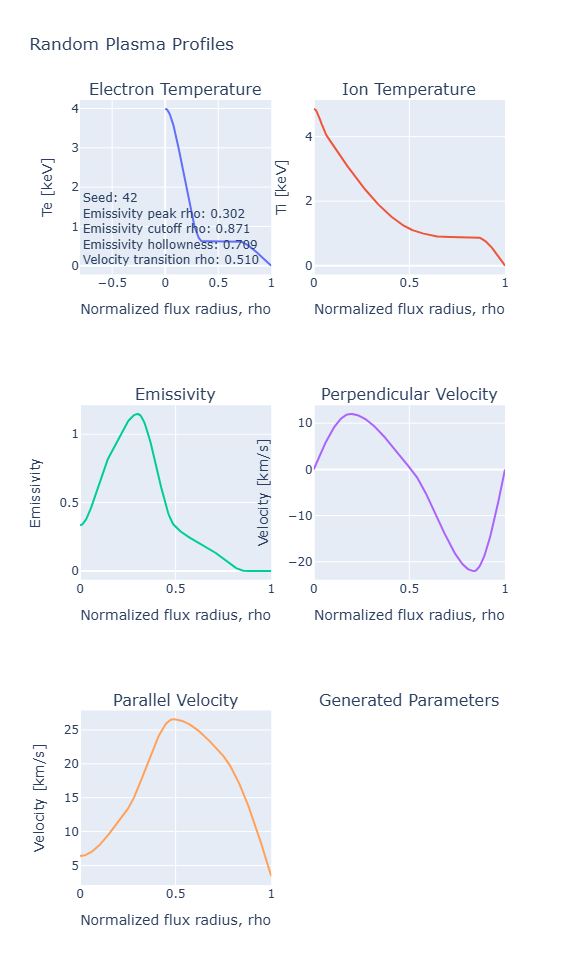

In [28]:
# practicing plotting the plama profiles
profiles, parameters = generate_plasma_profiles(
    seed=42,
)

figure = plot_plasma_profiles(
    profiles,
    parameters,
)

figure.show()

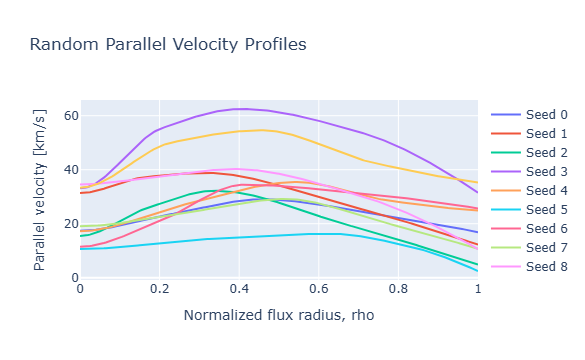

In [29]:
figure = go.Figure()

for seed in range(10):
    profiles, parameters = generate_plasma_profiles(
        seed=seed,
    )

    figure.add_trace(
        go.Scatter(
            x=profiles["rho"],
            y=profiles["parallel_velocity"],
            mode="lines",
            name=f"Seed {seed}",
        )
    )

figure.update_layout(
    title="Random Parallel Velocity Profiles",
    xaxis_title="Normalized flux radius, rho",
    yaxis_title="Parallel velocity [km/s]",
)

figure.show()